# D.R.O.N.A. — 02 · Exploratory Data Analysis

Statistical portraits of every dataset cleaned in notebook 01: distributions,
missingness, correlations, class balance, curriculum↔market alignment, and the
gesture-demonstration corpus.

```
01 data cleaning  ->  02 EDA  ->  03 feature engineering  ->  04 model training  ->  05 evaluation
   & preprocessing                   (dual embeddings)          (Colab A100)          & comparison
```

**Runtime:** CPU is enough (~5 min). **Inputs:** `data/processed/*`,
`data/finetune/*`, `data/demonstrations/*` (auto-regenerated if missing).
**Outputs:** publication-ready figures in `reports/figures/02_eda/`.

## 0 · Colab setup

In [21]:
import os, sys, subprocess, pathlib

gpu = ""
try:
    gpu = subprocess.run(["nvidia-smi", "-L"], capture_output=True, text=True, check=False).stdout.strip()
except FileNotFoundError:
    gpu = "No GPU detected - nvidia-smi command not found."
print(gpu or "No GPU detected - see the note at the top of this notebook.")

# EDIT this to your GitHub repo URL. Private repo? use a fine-grained read
# token: https://<TOKEN>@github.com/<user>/D.R.O.N.A.git
# Alternatively upload a zip of the project (Colab Files panel) or attach it
# as a Kaggle dataset named 'drona' - the search loop below finds it.
REPO_URL = "https://github.com/trishan9/D.R.O.N.A.git"   # <-- EDIT ME

def _is_repo(p):
    return pathlib.Path(p, "drona", "__init__.py").is_file()

search = [".", "..", "../..", "D.R.O.N.A", "/content/D.R.O.N.A",
          "/kaggle/working/D.R.O.N.A", "/kaggle/input/drona/D.R.O.N.A", "/kaggle/input/drona"]
repo = next((p for p in search if _is_repo(p)), None)
if repo is None:
    dest = "/content/D.R.O.N.A" if pathlib.Path("/content").is_dir() else "D.R.O.N.A"
    subprocess.run(["git", "clone", "--depth", "1", REPO_URL, dest], check=True)
    repo = dest
assert repo and _is_repo(repo), (
    "Repo not found. Set REPO_URL to your GitHub URL, OR upload/attach the "
    "project, then re-run. See docs/COLAB_TRAINING_GUIDE.md.")
os.chdir(repo)
print("repo:", os.getcwd())

subprocess.run([sys.executable, "-m", "pip", "install", "-q", "-e", ".[eval]"], check=False)
print("setup complete - continue to the next cell")

No GPU detected - nvidia-smi command not found.
repo: /content/D.R.O.N.A
setup complete - continue to the next cell


In [22]:
# ── Load & VERIFY the real private data (curriculum) — RUN AFTER SETUP ────────
# The real curriculum ships separately in drona_private_data.zip (it is
# gitignored). This cell puts it into the repo and HARD-STOPS on placeholder
# data, so you never train on dummies. It uses a DIRECT in-notebook upload
# (no Google Drive needed): the file picker BLOCKS this cell until you choose the
# zip, so later cells cannot run without the data. Re-running is safe — once the
# data is present it does nothing.
import glob, os, pathlib, subprocess

REPO = next((p for p in (".", "/content/D.R.O.N.A", "D.R.O.N.A", "..")
             if pathlib.Path(p, "drona", "__init__.py").is_file()), ".")

def _real_curriculum_count():
    d = pathlib.Path(REPO, "data/raw/curriculum")
    files = list(d.glob("*.md")) if d.is_dir() else []
    return sum(1 for f in files
               if "DUMMY / PLACEHOLDER" not in f.read_text(encoding="utf-8", errors="ignore")[:200])

def _unzip(z):
    print("unzipping", z, "...")
    subprocess.run(["unzip", "-oq", z, "-d", REPO], check=True)

if _real_curriculum_count() >= 40:
    print(f"real curriculum already present ({_real_curriculum_count()} modules) - OK to proceed")
else:
    # Reuse a bundle already on disk (Files-panel upload, Drive, or a prior run).
    found = (glob.glob("drona_private_data.zip")
             + glob.glob("/content/drona_private_data.zip")
             + glob.glob(f"{REPO}/drona_private_data.zip")
             + glob.glob("../drona_private_data.zip")
             + glob.glob("/content/drive/MyDrive/**/drona_private_data.zip", recursive=True)
             + glob.glob("/kaggle/input/**/drona_private_data.zip", recursive=True))
    if found:
        _unzip(found[0])
    else:
        try:
            from google.colab import files
        except ImportError:
            files = None
        if files is not None:
            print("\n" + "=" * 64)
            print(">>> Upload drona_private_data.zip now — click 'Choose Files'. <<<")
            print("    It is in your project folder on your PC (~4 MB).")
            print("=" * 64 + "\n")
            uploaded = files.upload()          # BLOCKS until the upload finishes
            zname = next((n for n in uploaded if n.lower().endswith(".zip")), None)
            if zname:
                if not os.path.exists(zname):
                    pathlib.Path(zname).write_bytes(uploaded[zname])
                _unzip(zname)

    n = _real_curriculum_count()
    if n < 40:
        raise SystemExit(
            f"\n*** REAL CURRICULUM NOT LOADED (only {n} real module files) ***\n"
            "Re-run THIS cell and upload drona_private_data.zip when the picker appears.")
    print(f"real curriculum loaded: {n} module files across all programmes - OK to proceed")


real curriculum already present (87 modules) - OK to proceed


In [23]:
# Ensure the processed artifacts from notebook 01 exist; regenerate if missing.
import pathlib, subprocess, sys

needed = ["data/processed/onet_career_pathways.parquet",
          "data/processed/onet_career_pathways.json",
          "data/processed/curriculum_modules.json",
          "data/processed/manual_postings.json",
          "data/finetune/sft_train.jsonl",
          "data/demonstrations/demonstrations.jsonl"]
missing = [p for p in needed if not pathlib.Path(p).exists()]
if missing:
    print("missing artifacts:", *missing, sep="\n  ")
    print("\nregenerating with scripts/prepare_training_data.py "
          "(or run notebook 01 for the audited version) ...")
    subprocess.run([sys.executable, "scripts/prepare_training_data.py"], check=True)
print("all pipeline inputs present")

all pipeline inputs present


In [24]:
# --- Shared plotting style: colorblind-safe palette, publication defaults ----
import random, pathlib
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

SEED = 42
random.seed(SEED); np.random.seed(SEED)

# Categorical palette - CVD-validated ordering. Never reorder or cycle it;
# a 9th series folds into "other".
C = ["#2a78d6", "#1baf7a", "#eda100", "#008300",
     "#4a3aa7", "#e34948", "#e87ba4", "#eb6834"]
INK = {"primary": "#0b0b0b", "secondary": "#52514e", "muted": "#898781",
       "grid": "#e1e0d9", "axis": "#c3c2b7", "surface": "#fcfcfb"}
SEQ = LinearSegmentedColormap.from_list("drona_seq",
    ["#cde2fb", "#9ec5f4", "#6da7ec", "#3987e5", "#256abf", "#184f95", "#0d366b"])
DIV = LinearSegmentedColormap.from_list("drona_div",
    ["#104281", "#5598e7", "#f0efec", "#e88a89", "#a52827"])

mpl.rcParams.update({
    "figure.dpi": 110, "savefig.dpi": 200, "savefig.bbox": "tight",
    "figure.facecolor": INK["surface"], "axes.facecolor": INK["surface"],
    "axes.edgecolor": INK["axis"], "axes.linewidth": 0.8,
    "axes.grid": True, "grid.color": INK["grid"], "grid.linewidth": 0.6,
    "axes.axisbelow": True, "axes.spines.top": False, "axes.spines.right": False,
    "axes.titlelocation": "left", "axes.titleweight": "bold", "axes.titlesize": 12,
    "axes.labelcolor": INK["secondary"], "axes.labelsize": 10,
    "xtick.color": INK["muted"], "ytick.color": INK["muted"],
    "xtick.labelsize": 9, "ytick.labelsize": 9,
    "text.color": INK["primary"], "font.family": "sans-serif",
    "legend.frameon": False, "legend.fontsize": 9,
    "axes.prop_cycle": mpl.cycler(color=C),
})

FIG_DIR = pathlib.Path("reports/figures/02_eda")
FIG_DIR.mkdir(parents=True, exist_ok=True)

def finish(ax, title, subtitle=None, xlabel=None, ylabel=None, grid_axis="y"):
    """Standard title/label treatment. grid_axis: which axis keeps gridlines."""
    ax.set_title(title, pad=22 if subtitle else 8)
    if subtitle:
        ax.text(0, 1.03, subtitle, transform=ax.transAxes,
                fontsize=9, color=INK["secondary"])
    if xlabel: ax.set_xlabel(xlabel)
    if ylabel: ax.set_ylabel(ylabel)
    ax.grid(visible=False, axis="x" if grid_axis == "y" else "y")
    return ax

def save_fig(fig, name):
    p = FIG_DIR / f"{name}.png"
    fig.savefig(p)
    print(f"figure saved -> {p}")

print("plot style ready; figures ->", FIG_DIR)

plot style ready; figures -> reports/figures/02_eda


## 1 · Load the processed artifacts

In [25]:
import json
from pathlib import Path

pathways = json.loads(Path("data/processed/onet_career_pathways.json").read_text(encoding="utf-8"))
modules  = json.loads(Path("data/processed/curriculum_modules.json").read_text(encoding="utf-8"))
postings = json.loads(Path("data/processed/manual_postings.json").read_text(encoding="utf-8"))

pw   = pd.json_normalize(pathways)
mod  = pd.json_normalize(modules)
jobs = pd.json_normalize(postings)

# derived numeric features (mirrors notebook 01 §7)
pw["n_skills"]  = pw["typical_skills"].str.len()
pw["n_modules"] = pw["related_softwarica_modules"].str.len()
pw["desc_len"]  = pw["description"].str.len()
pw["salary_lo_usd"] = pw["international_salary_range_usd"].map(
    lambda t: float(t[0]) if isinstance(t, (list, tuple)) else np.nan)
pw["salary_hi_usd"] = pw["international_salary_range_usd"].map(
    lambda t: float(t[1]) if isinstance(t, (list, tuple)) else np.nan)

print(f"pathways={len(pw)}  modules={len(mod)}  postings={len(jobs)}")

pathways=39  modules=87  postings=297


## 2 · Career pathways

The knowledge base the advisor cites. First the summary statistics, then
distributions of the fields that drive retrieval quality.

In [26]:
pw[["n_skills", "n_modules", "desc_len", "salary_lo_usd", "salary_hi_usd"]].describe().round(1)

,n_skills,n_modules,desc_len,salary_lo_usd,salary_hi_usd
count,39.0,39.0,39.0,38.0,38.0
mean,22.4,0.0,311.4,62694.2,182711.3
std,6.3,0.0,160.4,11705.5,25009.3
min,0.0,0.0,47.0,40980.0,100540.0
25%,25.0,0.0,187.0,55940.0,167185.0
50%,25.0,0.0,298.0,58970.0,188470.0
75%,25.0,0.0,425.5,67340.0,199670.0
max,25.0,0.0,689.0,86240.0,230630.0


figure saved -> reports/figures/02_eda/pathway_distributions.png


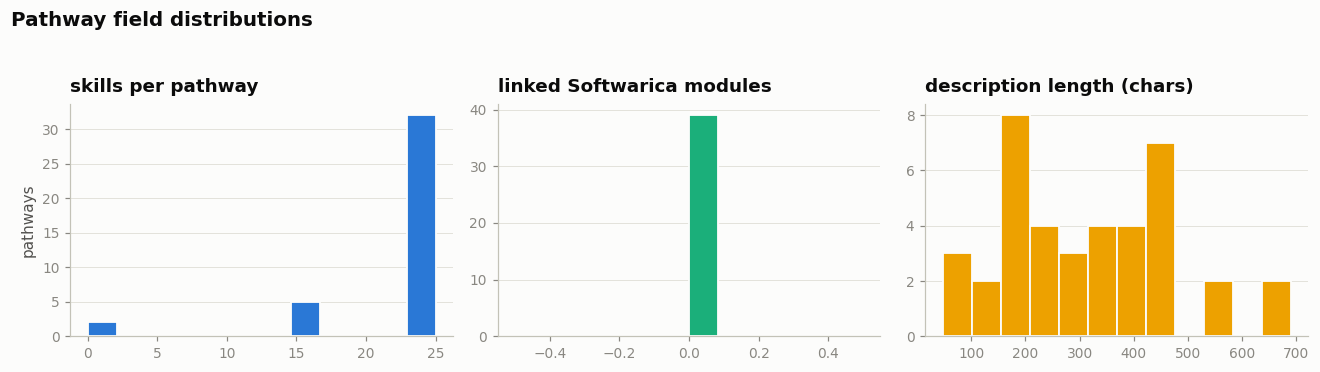

In [27]:
fig, axes = plt.subplots(1, 3, figsize=(12, 3.4))
for ax, col, label, color in [
        (axes[0], "n_skills",  "skills per pathway",  C[0]),
        (axes[1], "n_modules", "linked Softwarica modules", C[1]),
        (axes[2], "desc_len",  "description length (chars)", C[2])]:
    ax.hist(pw[col].dropna(), bins=12, color=color, edgecolor=INK["surface"], linewidth=1.2)
    finish(ax, label, ylabel="pathways" if ax is axes[0] else None)
fig.suptitle("Pathway field distributions", x=0.005, ha="left",
             fontweight="bold", fontsize=13)
fig.tight_layout(rect=(0, 0, 1, 0.94))
save_fig(fig, "pathway_distributions")
plt.show()

figure saved -> reports/figures/02_eda/pathway_top_skills.png


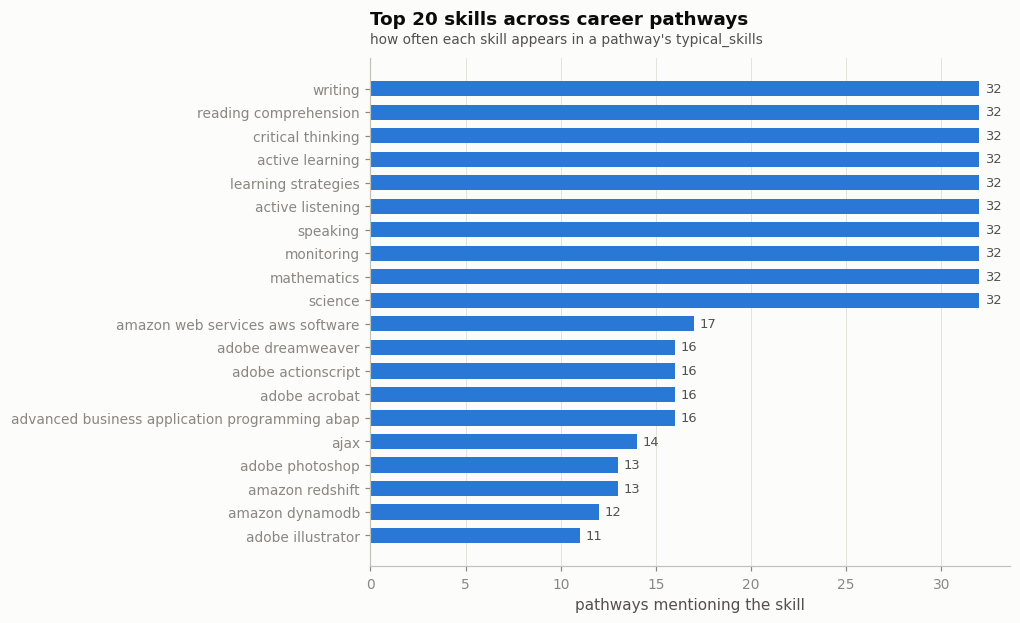

In [28]:
from collections import Counter

skill_counts = Counter(s.lower() for skills in pw["typical_skills"] for s in skills)
top = pd.Series(skill_counts).sort_values().tail(20)

fig, ax = plt.subplots(figsize=(7.5, 6))
bars = ax.barh(top.index, top.values, color=C[0], height=0.65)
for b, v in zip(bars, top.values):
    ax.text(b.get_width() + 0.3, b.get_y() + b.get_height() / 2, str(v),
            va="center", fontsize=8.5, color=INK["secondary"])
finish(ax, "Top 20 skills across career pathways",
       subtitle="how often each skill appears in a pathway's typical_skills",
       xlabel="pathways mentioning the skill", grid_axis="x")
save_fig(fig, "pathway_top_skills")
plt.show()

figure saved -> reports/figures/02_eda/pathway_salary_bands.png


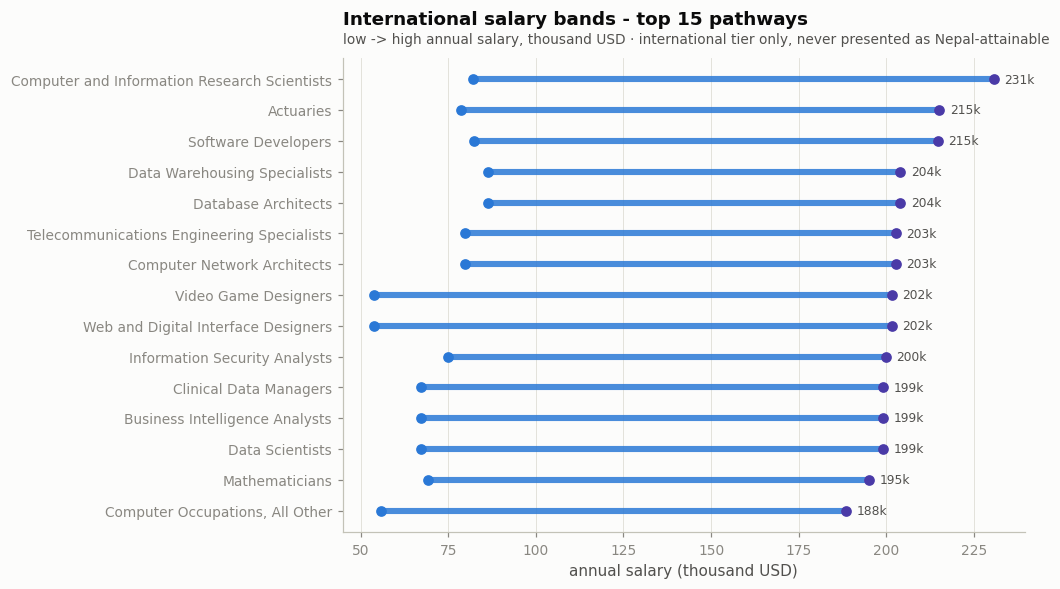

In [29]:
sal = pw.dropna(subset=["salary_lo_usd", "salary_hi_usd"]).nlargest(15, "salary_hi_usd")
sal = sal.sort_values("salary_hi_usd")

if len(sal):
    fig, ax = plt.subplots(figsize=(8, 5.6))
    ax.hlines(sal["title"], sal["salary_lo_usd"] / 1000, sal["salary_hi_usd"] / 1000,
              color=C[0], linewidth=4, alpha=0.85)
    ax.plot(sal["salary_lo_usd"] / 1000, sal["title"], "o", color=C[0], markersize=6)
    ax.plot(sal["salary_hi_usd"] / 1000, sal["title"], "o", color=C[4], markersize=6)
    for _, r in sal.iterrows():
        ax.text(r["salary_hi_usd"] / 1000 + 3, r["title"], f"{r['salary_hi_usd']/1000:.0f}k",
                va="center", fontsize=8, color=INK["secondary"])
    finish(ax, "International salary bands - top 15 pathways",
           subtitle="low -> high annual salary, thousand USD · international tier only, never presented as Nepal-attainable",
           xlabel="annual salary (thousand USD)", grid_axis="x")
    save_fig(fig, "pathway_salary_bands")
    plt.show()
else:
    print("No international salary bands yet - they attach via the optional BLS OEWS")
    print("enrichment (notebook 01 §3). Add the OEWS table to data/raw/bls/ and re-run 01.")

## 3 · Missingness map

Where the knowledge base has honest gaps (nothing was imputed in 01).

figure saved -> reports/figures/02_eda/pathway_missingness_matrix.png


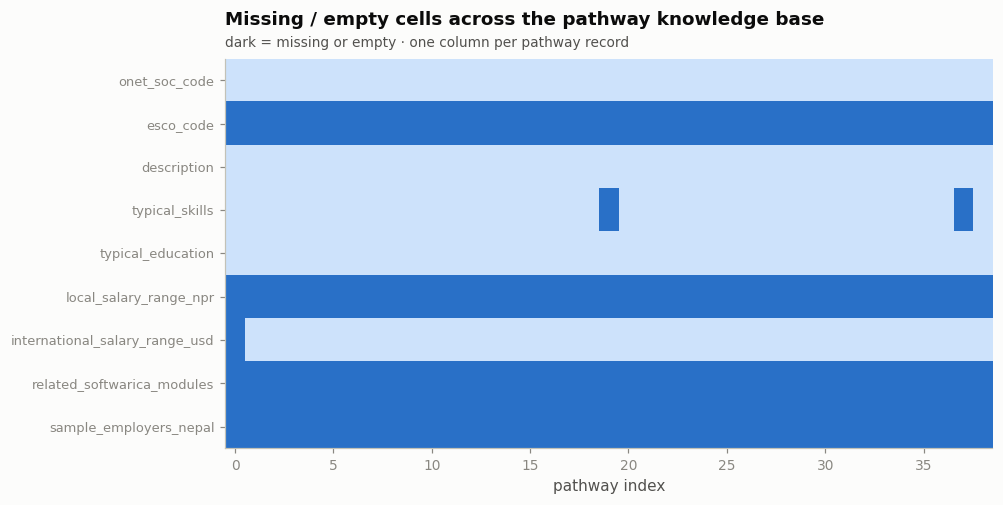

In [30]:
check_cols = ["onet_soc_code", "esco_code", "description", "typical_skills",
              "typical_education", "local_salary_range_npr",
              "international_salary_range_usd", "related_softwarica_modules",
              "sample_employers_nepal"]
isna = pd.DataFrame({c: (pw[c].isna() if pw[c].dtype != object
                         else pw[c].map(lambda v: v is None or (isinstance(v, list) and not v)))
                     for c in check_cols})

fig, ax = plt.subplots(figsize=(9, 4.6))
ax.imshow(isna.T.astype(int), aspect="auto", cmap=SEQ, vmin=0, vmax=1.6, interpolation="nearest")
ax.set_yticks(range(len(check_cols)), check_cols, fontsize=8.5)
finish(ax, "Missing / empty cells across the pathway knowledge base",
       subtitle="dark = missing or empty · one column per pathway record",
       xlabel="pathway index", grid_axis="x")
ax.grid(visible=False)
save_fig(fig, "pathway_missingness_matrix")
plt.show()

## 4 · Correlations between numeric pathway features

Pearson correlations on the engineered numeric features. With n≈39 these are
descriptive, not inferential - used to spot redundancy before feature
engineering, not to claim effects.

figure saved -> reports/figures/02_eda/pathway_correlations.png


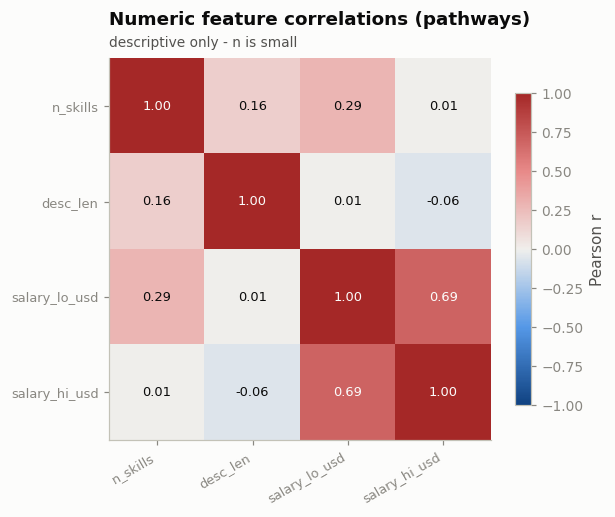

In [31]:
num = pw[["n_skills", "n_modules", "desc_len", "salary_lo_usd", "salary_hi_usd"]]
num = num.dropna(axis=1, how="all")            # optional enrichments may be absent
num = num.loc[:, num.nunique() > 1]            # constant columns have no correlation
corr = num.corr(numeric_only=True)

fig, ax = plt.subplots(figsize=(5.6, 4.6))
im = ax.imshow(corr, cmap=DIV, vmin=-1, vmax=1)
ax.set_xticks(range(len(corr)), corr.columns, rotation=30, ha="right", fontsize=8.5)
ax.set_yticks(range(len(corr)), corr.columns, fontsize=8.5)
for i in range(len(corr)):
    for j in range(len(corr)):
        v = corr.iloc[i, j]
        ax.text(j, i, f"{v:.2f}", ha="center", va="center", fontsize=8.5,
                color=INK["surface"] if abs(v) > 0.6 else INK["primary"])
fig.colorbar(im, ax=ax, shrink=0.8, label="Pearson r")
finish(ax, "Numeric feature correlations (pathways)",
       subtitle="descriptive only - n is small", grid_axis="x")
ax.grid(visible=False)
save_fig(fig, "pathway_correlations")
plt.show()

## 5 · Curriculum corpus

figure saved -> reports/figures/02_eda/curriculum_overview.png


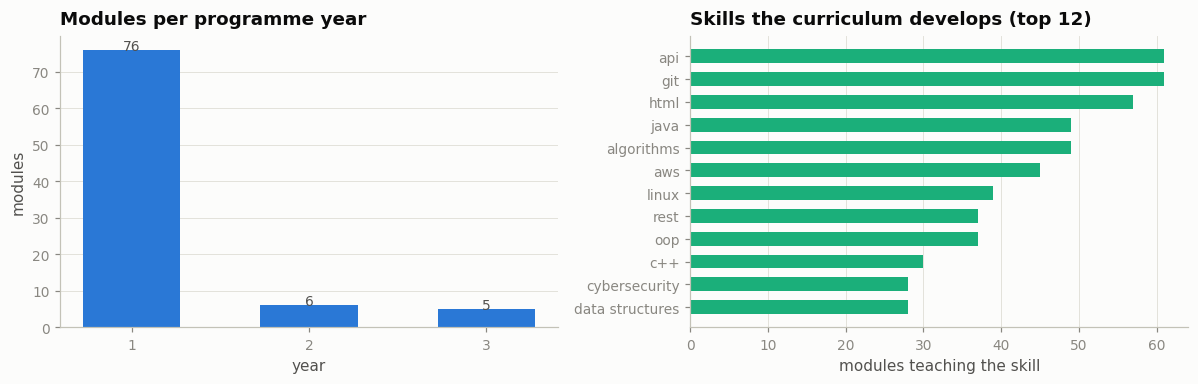

In [32]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.6))

by_year = mod.groupby("year").size()
axes[0].bar(by_year.index.astype(str), by_year.values, color=C[0], width=0.55)
for x, v in zip(by_year.index.astype(str), by_year.values):
    axes[0].text(x, v + 0.05, str(v), ha="center", fontsize=9, color=INK["secondary"])
finish(axes[0], "Modules per programme year", xlabel="year", ylabel="modules")

skill_counts = pd.Series([s.lower() for sk in mod["skills_developed"] for s in sk]).value_counts()
top = skill_counts.sort_values().tail(12)
axes[1].barh(top.index, top.values, color=C[1], height=0.6)
finish(axes[1], "Skills the curriculum develops (top 12)",
       xlabel="modules teaching the skill", grid_axis="x")

fig.tight_layout()
save_fig(fig, "curriculum_overview")
plt.show()

## 6 · Nepali job postings

figure saved -> reports/figures/02_eda/jobs_overview.png


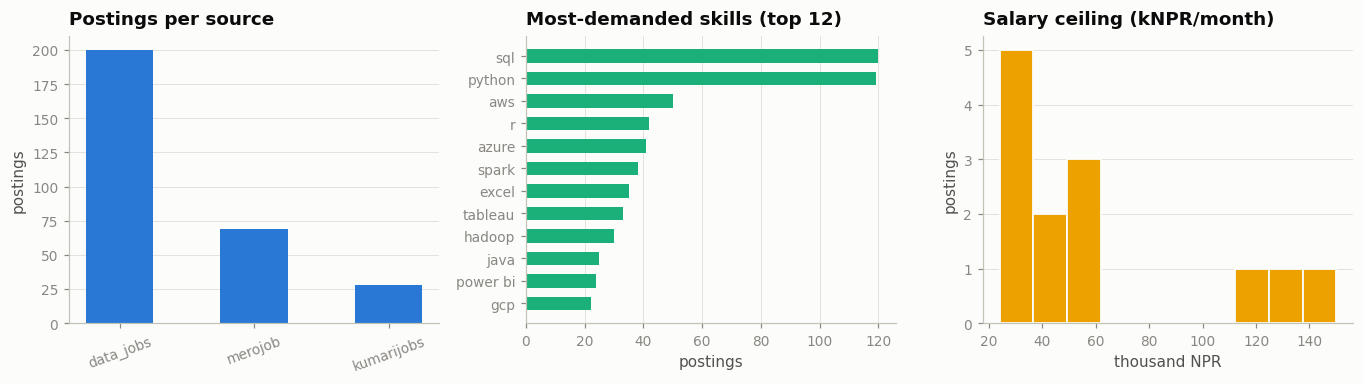

In [33]:
fig, axes = plt.subplots(1, 3, figsize=(12.5, 3.6))

src = jobs["source"].value_counts()
axes[0].bar(src.index, src.values, color=C[0], width=0.5)
finish(axes[0], "Postings per source", ylabel="postings")
axes[0].tick_params(axis="x", rotation=20)

demand = pd.Series([s.lower() for sk in jobs["skills_required"] for s in sk]).value_counts()
topd = demand.sort_values().tail(12)
axes[1].barh(topd.index, topd.values, color=C[1], height=0.6)
finish(axes[1], "Most-demanded skills (top 12)", xlabel="postings", grid_axis="x")

sal_npr = jobs["salary_max_npr"].dropna().astype(float) / 1000
if len(sal_npr):
    axes[2].hist(sal_npr, bins=10, color=C[2], edgecolor=INK["surface"], linewidth=1.2)
finish(axes[2], "Salary ceiling (kNPR/month)", xlabel="thousand NPR", ylabel="postings")

fig.tight_layout()
save_fig(fig, "jobs_overview")
plt.show()

## 7 · Curriculum ↔ market alignment

The question an advisee actually cares about: *are the skills employers ask
for taught somewhere in the programme?* Coverage below is exact-match on
normalised skill names, so it understates true coverage (e.g. "js" vs
"javascript") - treated as a lower bound.

exact-match coverage of top-15 demanded skills: 53%
figure saved -> reports/figures/02_eda/curriculum_market_alignment.png


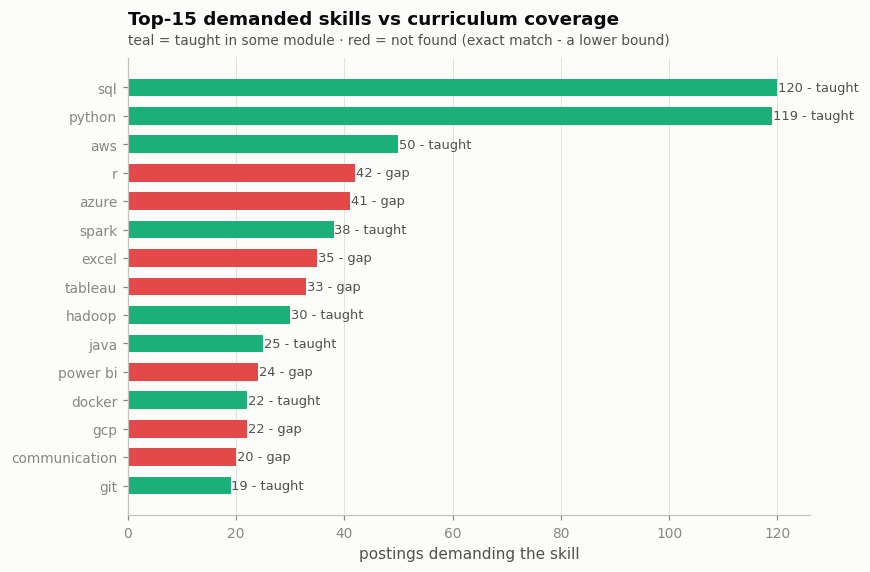

In [34]:
taught = {s.lower() for sk in mod["skills_developed"] for s in sk}
demand = pd.Series([s.lower() for sk in jobs["skills_required"] for s in sk]).value_counts()
top15 = demand.head(15)
covered = [s in taught for s in top15.index]

fig, ax = plt.subplots(figsize=(8, 5.4))
colors = [C[1] if c else C[5] for c in covered]
bars = ax.barh(top15.index[::-1], top15.values[::-1], color=colors[::-1], height=0.62)
for b, v, c in zip(bars, top15.values[::-1], covered[::-1]):
    ax.text(b.get_width() + 0.15, b.get_y() + b.get_height() / 2,
            f"{v} - {'taught' if c else 'gap'}", va="center", fontsize=8.5,
            color=INK["secondary"])
finish(ax, "Top-15 demanded skills vs curriculum coverage",
       subtitle="teal = taught in some module · red = not found (exact match - a lower bound)",
       xlabel="postings demanding the skill", grid_axis="x")
cov = 100 * sum(covered) / len(covered)
print(f"exact-match coverage of top-15 demanded skills: {cov:.0f}%")
save_fig(fig, "curriculum_market_alignment")
plt.show()

figure saved -> reports/figures/02_eda/module_skill_heatmap.png


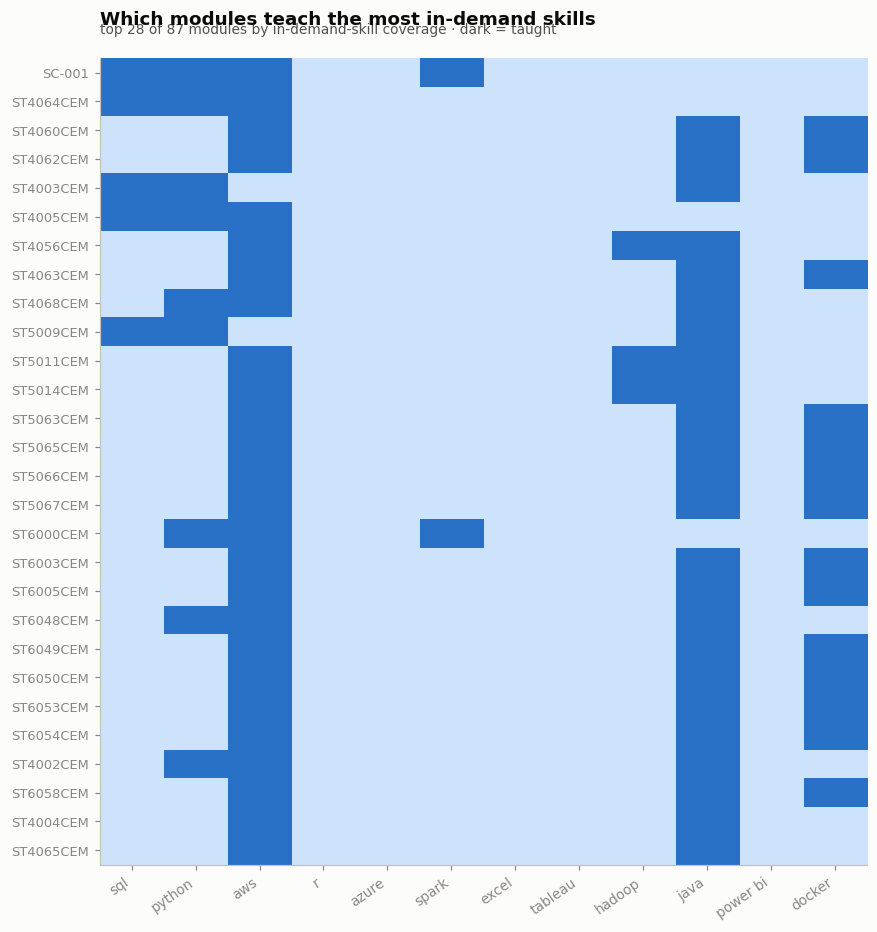

In [35]:
top_sk = list(demand.head(12).index)
# Keep only modules that teach >=1 in-demand skill (blank rows are pure noise) and
# rank by coverage, so the chart answers "which modules teach the most demanded
# skills" legibly instead of cramming all 87 module codes onto the axis.
rows = []
for _, m in mod.iterrows():
    low = {s.lower() for s in m["skills_developed"]}
    vec = [1 if s in low else 0 for s in top_sk]
    if sum(vec):
        rows.append((m["module_code"], sum(vec), vec))
rows.sort(key=lambda r: r[1], reverse=True)
rows = rows[:28]                                   # cap for readability
labels = [r[0] for r in rows]
grid = np.array([r[2] for r in rows]) if rows else np.zeros((1, len(top_sk)))

fig, ax = plt.subplots(figsize=(9, max(4.0, 0.34 * len(labels))))
ax.imshow(grid, cmap=SEQ, vmin=0, vmax=1.6, aspect="auto", interpolation="nearest")
ax.set_xticks(range(len(top_sk)), top_sk, rotation=35, ha="right", fontsize=9)
ax.set_yticks(range(len(labels)), labels, fontsize=8.5)
finish(ax, "Which modules teach the most in-demand skills",
       subtitle=f"top {len(labels)} of {len(mod)} modules by in-demand-skill coverage · dark = taught",
       grid_axis="x")
ax.grid(visible=False)
save_fig(fig, "module_skill_heatmap")
plt.show()


## 8 · SFT dataset (the LoRA training corpus)

Class balance across the six cognitive-bias types (a skewed balance would bias
C2), plus prompt/answer length distributions (drives `max_seq_length` in 04).

figure saved -> reports/figures/02_eda/sft_dataset.png


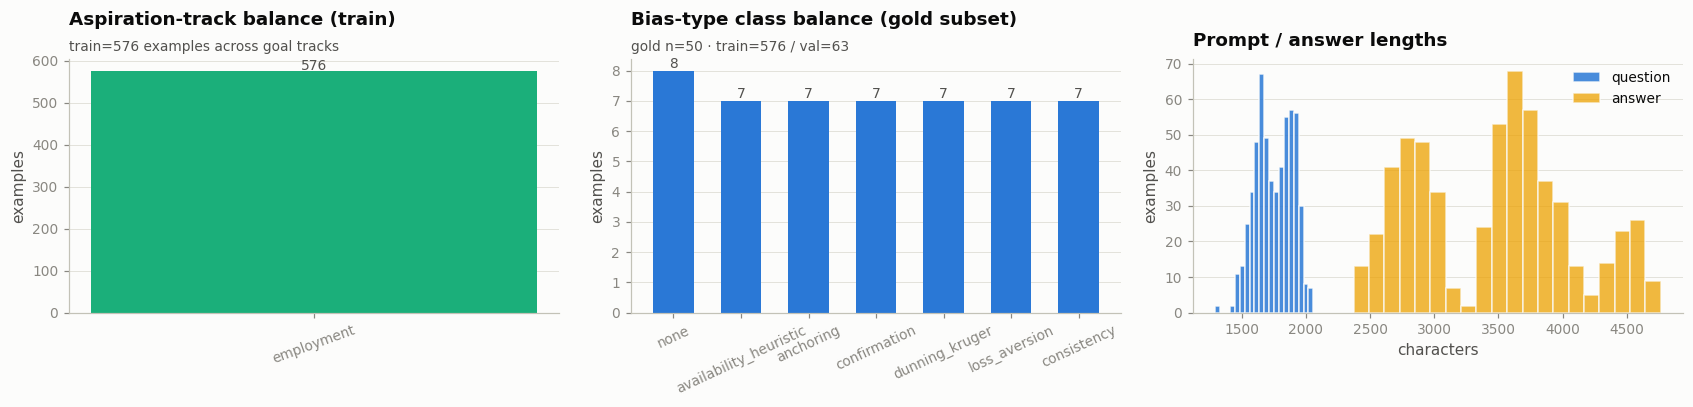

In [36]:
import json as _json

gold = [_json.loads(l) for l in open("data/finetune/gold_review.jsonl", encoding="utf-8")]
train = [_json.loads(l) for l in open("data/finetune/sft_train.jsonl", encoding="utf-8")]
val   = [_json.loads(l) for l in open("data/finetune/sft_val.jsonl", encoding="utf-8")]

GOAL_LABELS = {"employment": "employment", "postgrad_abroad": "postgrad\nabroad",
               "startup": "startup", "research": "research", "freelance": "freelance",
               "undecided": "undecided"}
goal = pd.Series([GOAL_LABELS.get(e.get("goal"), e.get("goal") or "employment")
                  for e in train]).value_counts()
bias = pd.Series([g.get("bias_type") or "none" for g in gold]).value_counts()

fig, axes = plt.subplots(1, 3, figsize=(15.5, 3.8))

# 1) Goal-track balance over the full train set - the multi-aspiration coverage (C2+).
axes[0].bar(goal.index, goal.values, color=C[1], width=0.7)
for x, v in enumerate(goal.values):
    axes[0].text(x, v + 1, str(v), ha="center", fontsize=9, color=INK["secondary"])
finish(axes[0], "Aspiration-track balance (train)",
       subtitle=f"train={len(train)} examples across goal tracks", ylabel="examples")
axes[0].tick_params(axis="x", rotation=20)

# 2) Bias-type balance over the gold subset.
axes[1].bar(bias.index, bias.values, color=C[0], width=0.6)
for x, v in enumerate(bias.values):
    axes[1].text(x, v + 0.1, str(v), ha="center", fontsize=9, color=INK["secondary"])
finish(axes[1], "Bias-type class balance (gold subset)",
       subtitle=f"gold n={len(gold)} · train={len(train)} / val={len(val)}", ylabel="examples")
axes[1].tick_params(axis="x", rotation=25)

# 3) Prompt / answer length distribution.
q_len = [len(e["messages"][1]["content"]) for e in train if len(e.get("messages", [])) > 1]
a_len = [len(e["messages"][-1]["content"]) for e in train if e.get("messages")]
axes[2].hist(q_len, bins=20, color=C[0], alpha=0.85, label="question",
             edgecolor=INK["surface"], linewidth=1.0)
axes[2].hist(a_len, bins=20, color=C[2], alpha=0.75, label="answer",
             edgecolor=INK["surface"], linewidth=1.0)
axes[2].legend()
finish(axes[2], "Prompt / answer lengths", xlabel="characters", ylabel="examples")

fig.tight_layout()
save_fig(fig, "sft_dataset")
plt.show()


## 9 · Gesture demonstrations

Balance, trajectory shapes, and smoothness of the imitation-learning corpus.
Jerk (third derivative of position) is the smoothness metric the C3 claim is
scored on, so its distribution in the *training data* is the reference point.

2026-07-14 06:15:29.003 | INFO     | drona.interaction.demonstration:load_jsonl:254 - Loaded 5000 frames from data/demonstrations/demonstrations.jsonl


figure saved -> reports/figures/02_eda/demo_class_balance.png


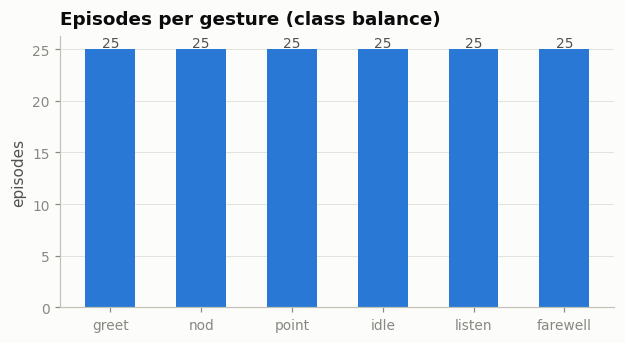

In [37]:
from drona.interaction.demonstration import DemonstrationDataset
from drona.evaluation.metrics import jerk_score
from pathlib import Path

demo = DemonstrationDataset.load_jsonl(Path("data/demonstrations/demonstrations.jsonl"))
labels = sorted({ep.gesture_label for ep in demo.episodes})

per_gesture = pd.Series([ep.gesture_label for ep in demo.episodes]).value_counts()
fig, ax = plt.subplots(figsize=(6.5, 3.2))
ax.bar(per_gesture.index, per_gesture.values, color=C[0], width=0.55)
for x, v in enumerate(per_gesture.values):
    ax.text(x, v + 0.2, str(v), ha="center", fontsize=9, color=INK["secondary"])
finish(ax, "Episodes per gesture (class balance)", ylabel="episodes")
save_fig(fig, "demo_class_balance")
plt.show()

figure saved -> reports/figures/02_eda/demo_trajectories.png


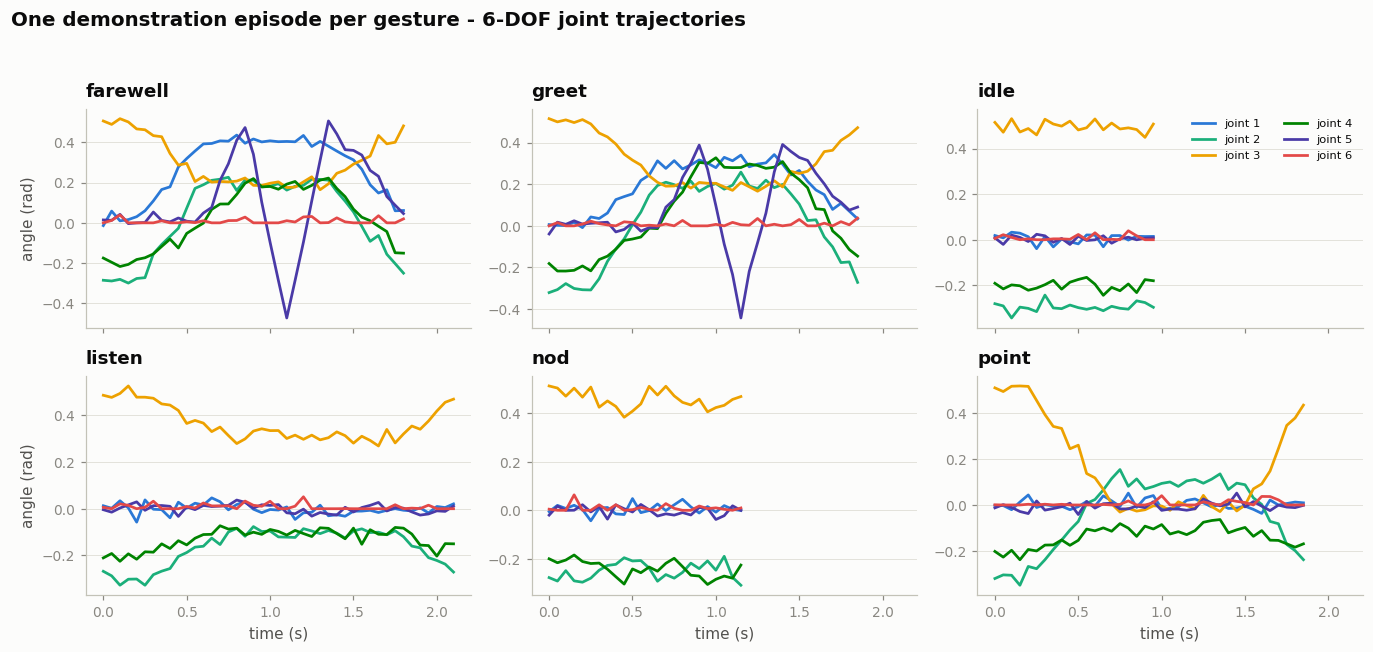

In [38]:
fig, axes = plt.subplots(2, 3, figsize=(12.5, 6), sharex=True)
for ax, g in zip(axes.flat, labels):
    ep = next(e for e in demo.episodes if e.gesture_label == g)
    traj = np.array([f.observation_state for f in ep.frames])
    t = np.arange(len(traj)) * 0.05
    for j in range(traj.shape[1]):
        ax.plot(t, traj[:, j], color=C[j], linewidth=1.8, label=f"joint {j+1}")
    finish(ax, g, ylabel="angle (rad)" if g in labels[::3] else None,
           xlabel="time (s)" if g in labels[3:] else None)
axes[0, 2].legend(ncols=2, fontsize=7.5)
fig.suptitle("One demonstration episode per gesture - 6-DOF joint trajectories",
             x=0.005, ha="left", fontweight="bold", fontsize=13)
fig.tight_layout(rect=(0, 0, 1, 0.95))
save_fig(fig, "demo_trajectories")
plt.show()

figure saved -> reports/figures/02_eda/demo_jerk_violin.png


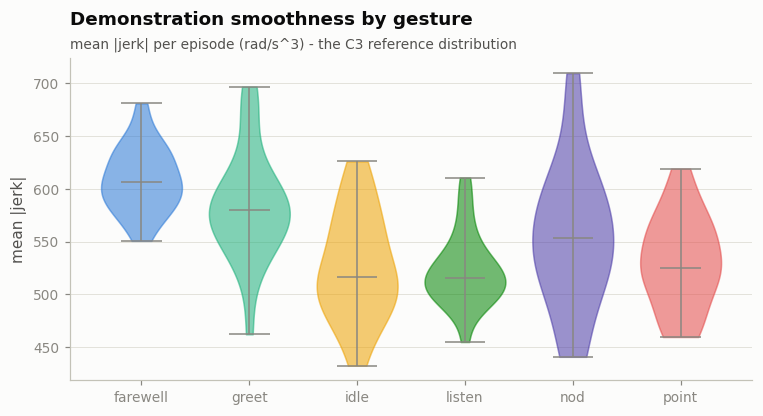

In [39]:
jerks = {g: [jerk_score([np.asarray(f.observation_state) for f in ep.frames])
             for ep in demo.episodes if ep.gesture_label == g] for g in labels}

fig, ax = plt.subplots(figsize=(8, 3.8))
parts = ax.violinplot([jerks[g] for g in labels], showmedians=True, widths=0.75)
for i, body in enumerate(parts["bodies"]):
    body.set_facecolor(C[i]); body.set_alpha(0.55); body.set_edgecolor(C[i])
for key in ("cmedians", "cbars", "cmins", "cmaxes"):
    parts[key].set_color(INK["muted"]); parts[key].set_linewidth(1)
ax.set_xticks(range(1, len(labels) + 1), labels)
finish(ax, "Demonstration smoothness by gesture",
       subtitle="mean |jerk| per episode (rad/s^3) - the C3 reference distribution",
       ylabel="mean |jerk|")
save_fig(fig, "demo_jerk_violin")
plt.show()

## 10 · Key findings

Auto-generated from the numbers above - re-runs stay in sync with the data.

In [40]:
taught_cov = 100 * sum(s in taught for s in demand.head(15).index) / 15
findings = f"""
1. Knowledge base   : {len(pw)} career pathways, {len(mod)} curriculum modules,
                      {len(jobs)} Nepal-tier postings - all schema-validated.
2. Honest gaps      : local NPR salary is the sparsest pathway field; nothing imputed,
                      the advising layer must cite around gaps rather than invent numbers.
3. Market alignment : {taught_cov:.0f}% of the top-15 demanded skills are taught
                      (exact-match lower bound) - the gap list above is advising material.
4. SFT balance      : all six bias types are represented in the gold subset;
                      answer lengths fit comfortably inside max_seq_length=2048.
5. Demonstrations   : perfectly balanced classes ({per_gesture.iloc[0]} episodes/gesture);
                      per-gesture jerk distributions give the smoothness bar that the
                      learned policies must beat in notebook 05.
"""
print(findings)


1. Knowledge base   : 39 career pathways, 87 curriculum modules,
                      297 Nepal-tier postings - all schema-validated.
2. Honest gaps      : local NPR salary is the sparsest pathway field; nothing imputed,
                      the advising layer must cite around gaps rather than invent numbers.
3. Market alignment : 53% of the top-15 demanded skills are taught
                      (exact-match lower bound) - the gap list above is advising material.
4. SFT balance      : all six bias types are represented in the gold subset;
                      answer lengths fit comfortably inside max_seq_length=2048.
5. Demonstrations   : perfectly balanced classes (25 episodes/gesture);
                      per-gesture jerk distributions give the smoothness bar that the
                      learned policies must beat in notebook 05.



---
**Next:** [03 · Feature Engineering](03_feature_engineering_embeddings.ipynb) -
turn these corpora into the dual-embedding feature space that retrieval (C1)
runs on.